In [1]:
import os, argparse, typing
os.chdir("../")

import numpy as np
import pandas as pd
import torch 

from PINN import models as models
from PINN import reader 
from PINN import functions as fns

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from PINN import pl

In [3]:
import scanpy as sc

## prepare the ery_mk anndata for training

In [4]:
ery_mk_ad = sc.read_h5ad("data/ery_mk.h5ad")

In [ ]:
ckpt_path

In [19]:
def load_model_DS(ckpt_path):

    ckpt_vx = torch.load(ckpt_path, map_location='cpu')
    
    modelvx = models.Cspline_woPL(**ckpt_vx['hyper_parameters'])
    modelvx.load_state_dict(ckpt_vx['state_dict'])

    
    n_grid = modelvx.n_grid
    nearby_cellstate = 300

    train_DS = reader.MeshGrid_AnnDS(AnnData=ery_mk_ad, cellstate_key='Actb_Kcnn4_scaled_S',
                                    n_grid=n_grid,  nearby_cellstate=nearby_cellstate, 
                                    collocation_points=300, n_repeat=10)
    
    return modelvx, train_DS

def predict_u(model, train_DS, device=None):
    
    s = train_DS.s
    ub_pred = []

    if device is None:
        device = model.device
    
    with torch.no_grad():
        for tb in train_DS.t_b:
            
            tb = torch.from_numpy(tb).float()
    
            u_pred_t = model.u(s.to(device), tb.to(device))
            ub_pred.append( u_pred_t.cpu().numpy() )
    
    torch.cuda.empty_cache()
    ub_pred = np.array(ub_pred)
    
    return ub_pred

def pred_vis(ckpt):
    model, train_DS = load_model_DS(ckpt)

    ub_pred = predict_u(model, train_DS)
    ub = train_DS.u_b

    fig, axs= pl.meshgrid_density_by_time(ub, ub_pred, train_DS, cellstate_1 = 'Actb', cellstate_2 = 'Kcnn4')

# Version 0

/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/pytorch_lightning/utilities/parsing.py:208: Attribute 'u' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['u'])`.


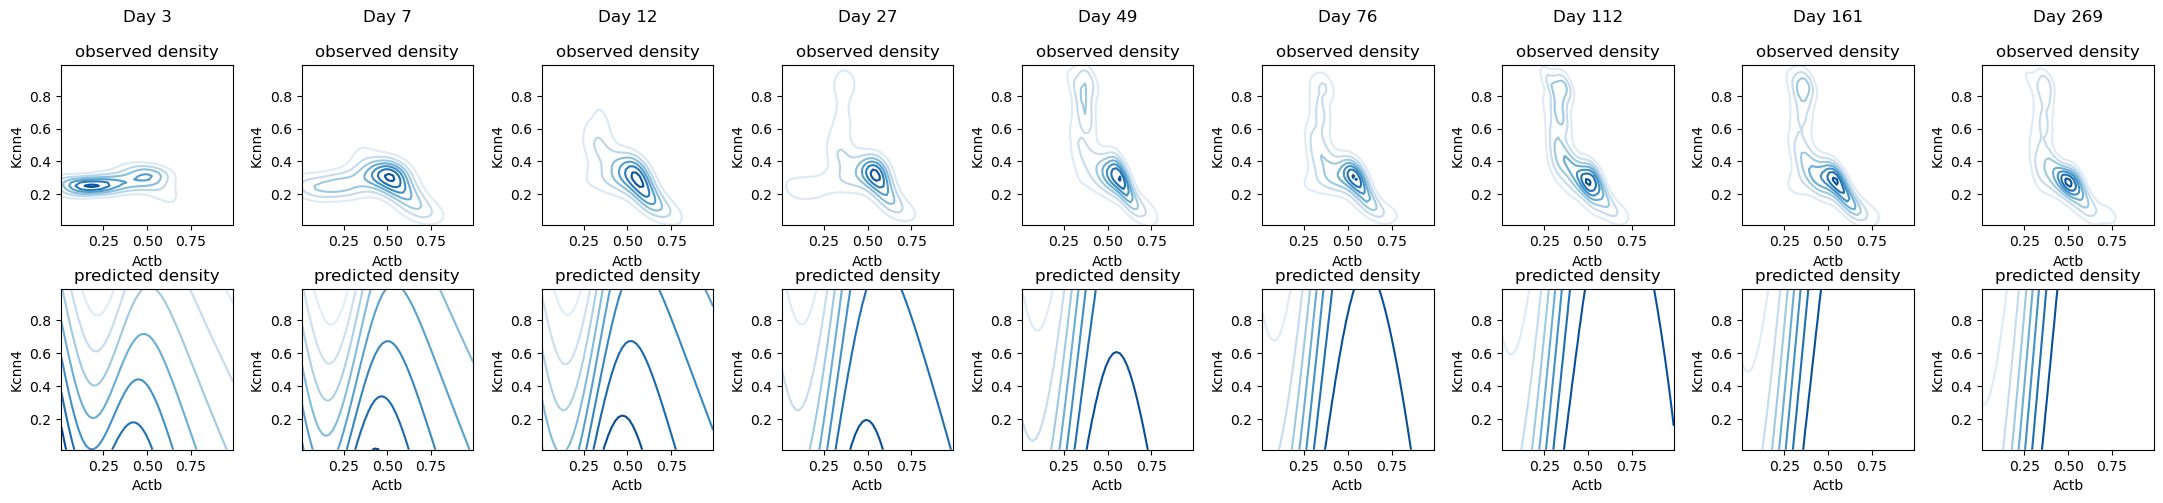

In [21]:
pred_vis("logs/ery_mk-Actb_Kcnn4_scaled_S_multiBnch/Cspline_woPL/lightning_logs/version_0/checkpoints/epoch=71-total_loss=0.00718598.ckpt")

# Version 1

/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/pytorch_lightning/utilities/parsing.py:208: Attribute 'u' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['u'])`.


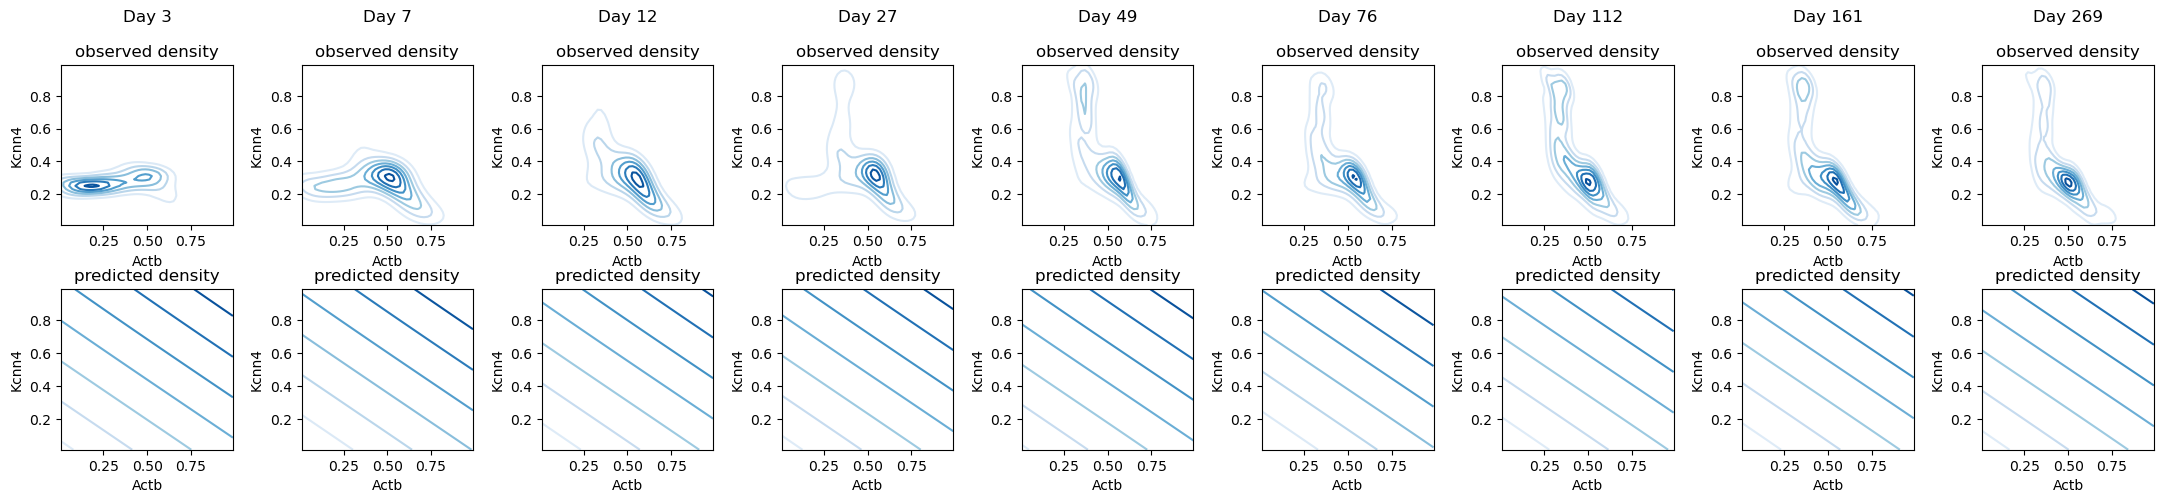

In [22]:
pred_vis("logs/ery_mk-Actb_Kcnn4_scaled_S_multiBnch/Cspline_woPL/lightning_logs/version_1/checkpoints/epoch=15-total_loss=0.01319083.ckpt")

# Version 2

/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/pytorch_lightning/utilities/parsing.py:208: Attribute 'u' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['u'])`.


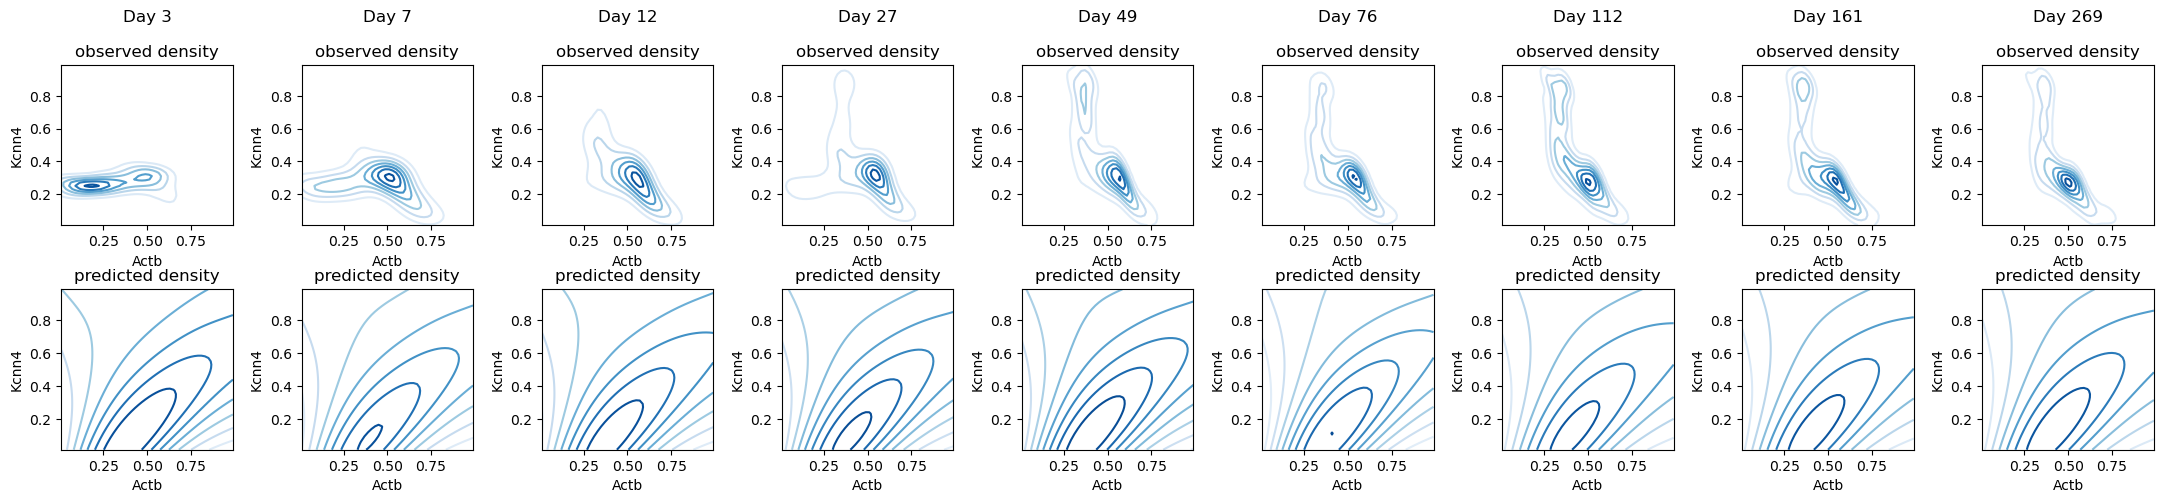

In [27]:
pred_vis('logs/ery_mk-Actb_Kcnn4_scaled_S_multiBnch/Cspline_woPL/lightning_logs/version_2/checkpoints/epoch=69-total_loss=0.00550373.ckpt')

# Version 3

/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/pytorch_lightning/utilities/parsing.py:208: Attribute 'u' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['u'])`.


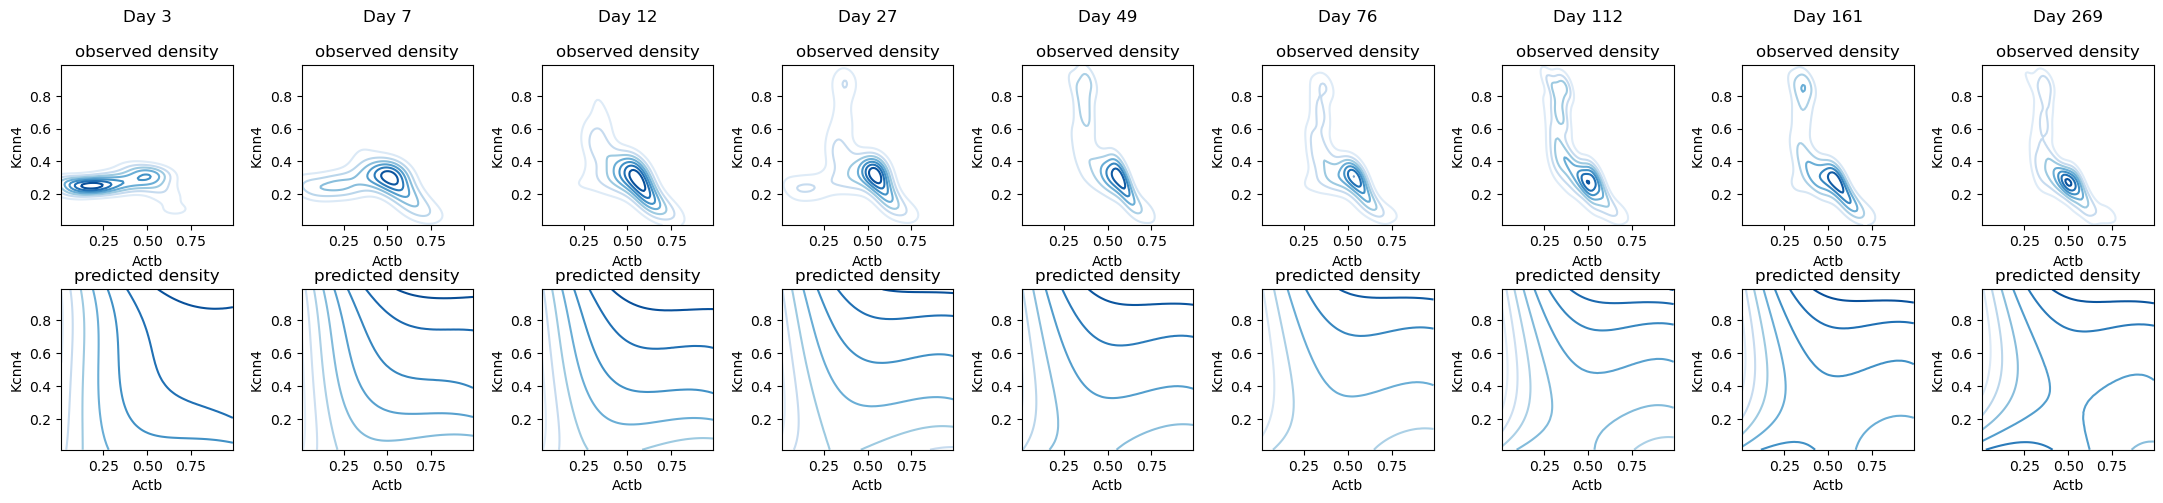

In [9]:
v3_ckpt = "logs/ery_mk-Actb_Kcnn4_scaled_S_multiBnch/Cspline_woPL/lightning_logs/version_3/checkpoints/epoch=2-total_loss=0.00030782.ckpt"

modelv3, train_DS = load_model_DS(v3_ckpt)

ub_pred = predict_u(modelv3, train_DS)
ub = train_DS.u_b

fig, axs= pl.meshgrid_density_by_time(ub, ub_pred, train_DS, cellstate_1 = 'Actb', cellstate_2 = 'Kcnn4')

# OLD

/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/pytorch_lightning/utilities/parsing.py:208: Attribute 'u' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['u'])`.


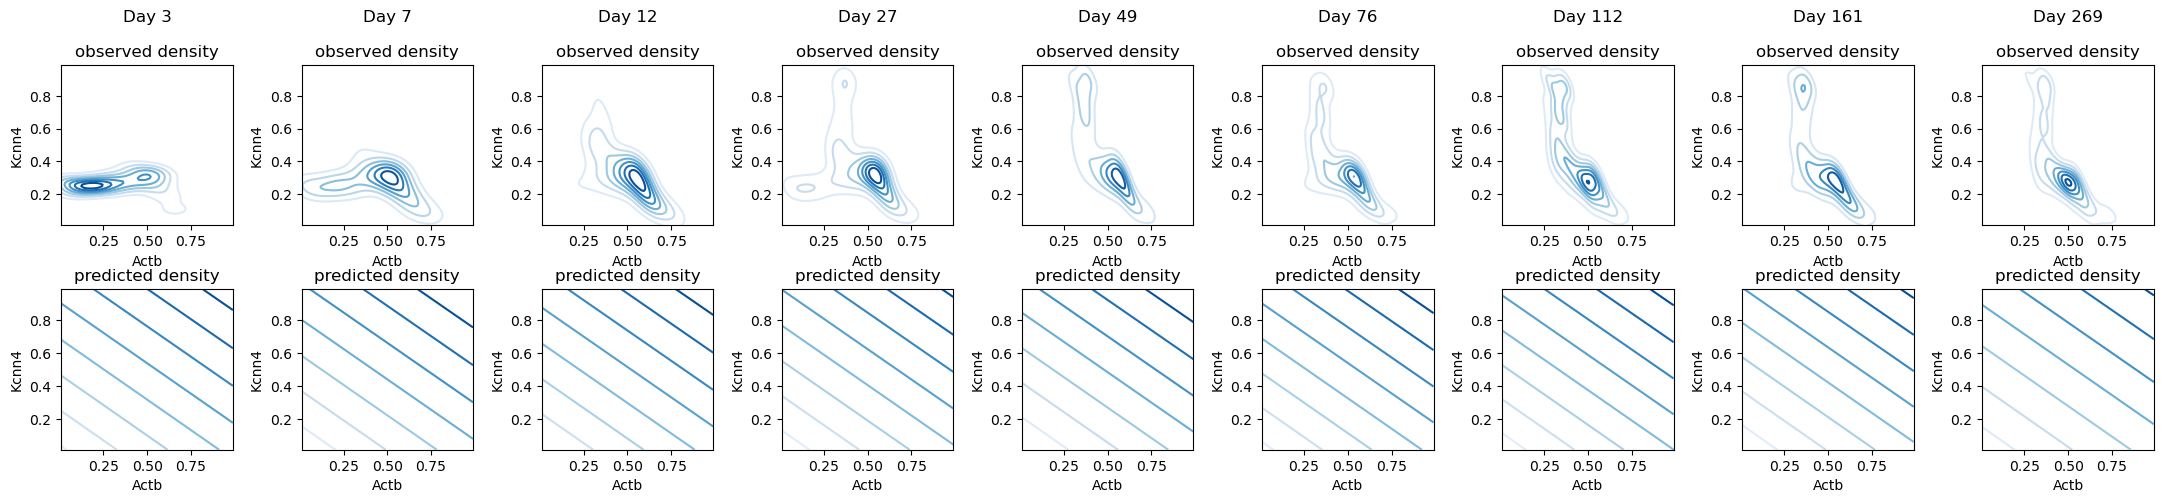

In [25]:
# v2
pred_vis("logs/ery_mk-Actb_Kcnn4_scaled_S_multiBnch/Cspline_woPL_old/lightning_logs/version_0/checkpoints/epoch=162-total_loss=0.00000578.ckpt")

/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/pytorch_lightning/utilities/parsing.py:208: Attribute 'u' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['u'])`.


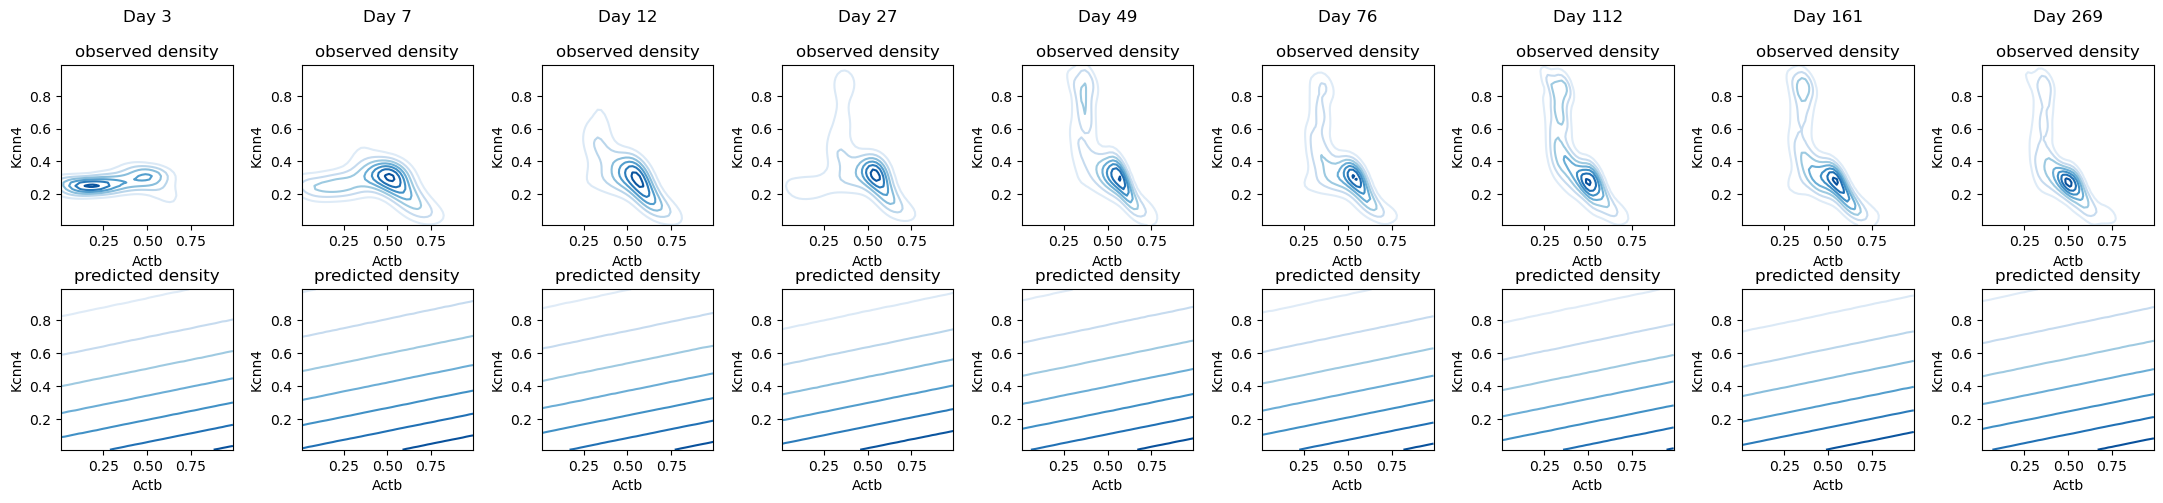

In [24]:
# v2
pred_vis("logs/ery_mk-Actb_Kcnn4_scaled_S_multiBnch/Cspline_woPL_old/lightning_logs/version_2/checkpoints/epoch=65-total_loss=0.00001415.ckpt")

/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/pytorch_lightning/utilities/parsing.py:208: Attribute 'u' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['u'])`.


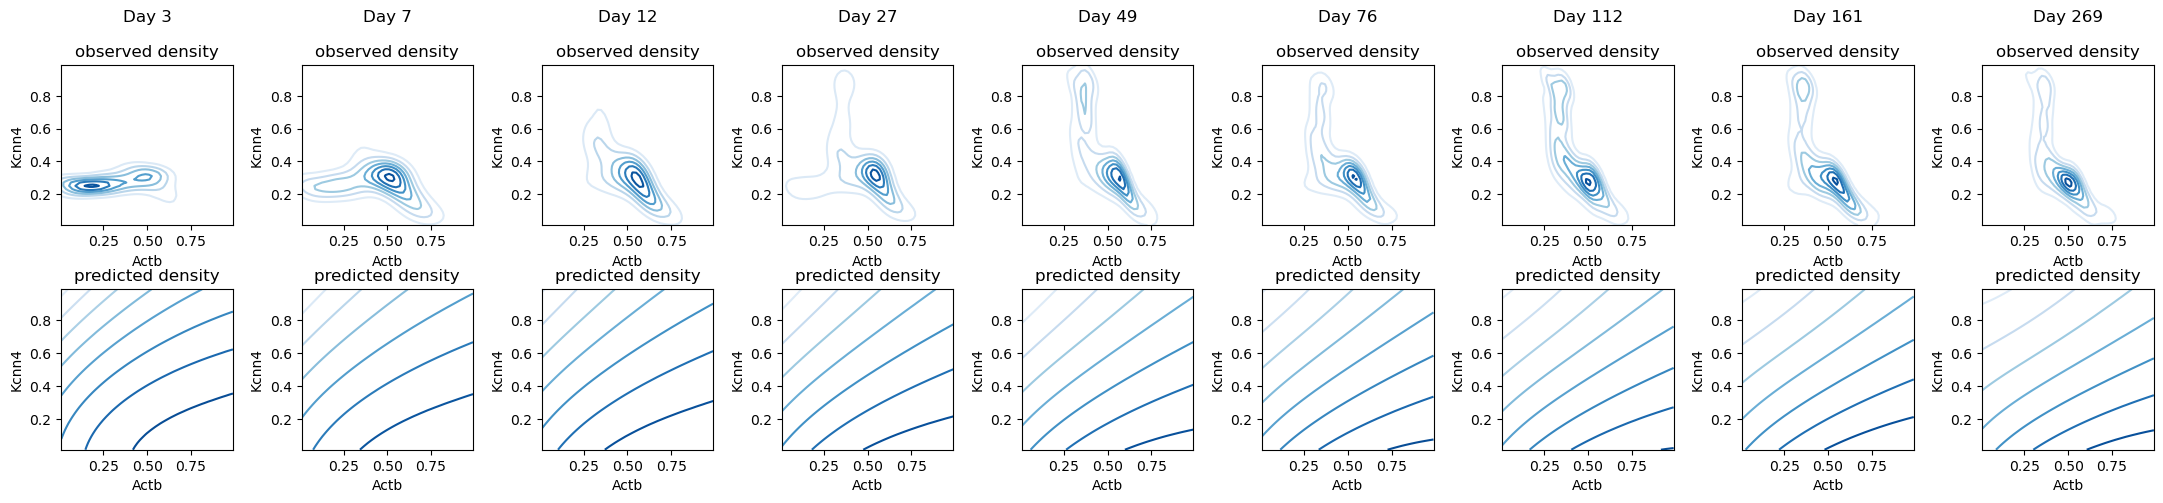

In [28]:
#v8
pred_vis("logs/ery_mk-Actb_Kcnn4_scaled_S_multiBnch/Cspline_woPL_old/lightning_logs/version_8/checkpoints/epoch=66-total_loss=0.00000045.ckpt")